(https://www.kaggle.com/datasets/shivamb/netflix-shows)
Датасет содержит информацию о фильмах и сериалах, доступных на платформе Netflix. В нем представлены такие признаки как название, тип контента (Movie / TV Show), год выхода, длительность, жанры, страна производства, возрастной рейтинг, краткое описание.

In [2]:
import pandas as pd
df = pd.read_csv('netflix_titles.csv')
df.head()
print(f"Размер датасета: {df.shape}")
display(df.head())
display(df.tail())


Размер датасета: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [7]:
import pandas as pd
df = pd.read_csv('netflix_titles.csv')
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [17]:
import pandas as pd
df = pd.read_csv('netflix_titles.csv')

df.describe(include=['object', 'string'])

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


In [16]:
import pandas as pd
df = pd.read_csv('netflix_titles.csv')
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)
df_dropped = df.dropna(subset=['date_added', 'duration_num'])
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown Cast')
mean_release_year = df['release_year'].mean()
df['release_year'] = df['release_year'].fillna(mean_release_year)
median_release_year = df['release_year'].median()
df['release_year'] = df['release_year'].fillna(median_release_year)
mode_country = df['country'].mode()[0]
df['country'] = df['country'].fillna(mode_country)



Удаляем строки, где нет очень важных данных.
Если не известен режиссер или актер, используем константу.
Для страны выбираем моду, тк большинство фильмов снято в США

In [11]:
years = df['release_year']
print(f"min = {years.min()}")
print(f"max = {years.max()}")
print(f"mean = {years.mean():.2f}")
print(f"median = {years.median()}")
print(f"mode = {years.mode()}")
print("\nquantile:")
print(years.quantile([0.05, 0.25, 0.5, 0.75, 0.95]))

min = 1925
max = 2021
mean = 2014.18
median = 2017.0
mode = 0    2018
Name: release_year, dtype: int64

quantile:
0.05    1997.0
0.25    2013.0
0.50    2017.0
0.75    2019.0
0.95    2021.0
Name: release_year, dtype: float64


Дисперсия - показатель того, насколько далеко числа стоят от среднего значения. Ассиметрия - мера несимметричности распределения относительно его центра.Эксцесс оказывает, насколько резко данные скапливаются в одном месте.
Для моих данных дисперсия получилась довольно большая, это значит годы выпуска сильно разбросаны  вокруг среднего значения. Ассиметрия отрицательная значит, что старые фильмы встречаются редко и тянут хвост графика влево. Показатель эксцесса высокий, что значит есть высокая концентрация фильмов в одном узком промежутке.

In [12]:
print(f"variance = {years.var():.2f}")
print(f"skewness = {years.skew():.2f}")
print(f"kurtosis = {years.kurt():.2f}")

variance = 77.78
skewness = -3.45
kurtosis = 16.23


In [10]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv('netflix_titles.csv')
cols = ['type', 'rating']
df_encoded = pd.get_dummies(df, columns =['type'])
print(df_encoded[['type_Movie', 'type_TV Show']].head())
le = LabelEncoder()
print("До:", df['rating'][:3])
df['rating_le'] = le.fit_transform(df['rating'].astype(str))
print("После:", df['rating_le'][:3])
df['is_Movie'] = (df['type'] == 'Movie').astype(int)
target_map = df.groupby('country')['is_Movie'].mean()
df['country_target'] = df['country'].map(target_map)
print(df[['country', 'is_Movie', 'country_target']].head())


   type_Movie  type_TV Show
0        True         False
1       False          True
2       False          True
3       False          True
4       False          True
До: 0    PG-13
1    TV-MA
2    TV-MA
Name: rating, dtype: str
После: 0     7
1    11
2    11
Name: rating_le, dtype: int64
         country  is_Movie  country_target
0  United States         1        0.730305
1   South Africa         0        0.800000
2            NaN         0             NaN
3            NaN         0             NaN
4          India         0        0.918724


In [6]:
import pandas as pd
from sklearn.feature_extraction import FeatureHasher
df = pd.read_csv('netflix_titles.csv')
genre_list = df['listed_in'].str.split(', ')
hasher = FeatureHasher(n_features = 5, input_type = 'string')
hashed = hasher.transform(genre_list).toarray()
names = [f'genre_hash_{i}' for i in range(5)]
df[names] = hashed
print(df[names].head())
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
country_count = df['country'].value_counts()
rare = country_count[country_count < 10].index
df['country_grouped'] = df['country'].replace(rare, 'Other')
cols_to_show = ['title', 'year_added', 'month_added', 'country_grouped']
print(df[cols_to_show].tail())

   genre_hash_0  genre_hash_1  genre_hash_2  genre_hash_3  genre_hash_4
0           1.0           0.0           0.0           0.0           0.0
1           0.0           0.0           0.0          -1.0           0.0
2           1.0           1.0          -1.0           0.0           0.0
3           0.0           1.0           0.0           0.0           1.0
4           0.0           0.0           0.0          -1.0           0.0
            title  year_added  month_added country_grouped
8802       Zodiac      2019.0         11.0   United States
8803  Zombie Dumb      2019.0          7.0             NaN
8804   Zombieland      2019.0         11.0   United States
8805         Zoom      2020.0          1.0   United States
8806       Zubaan      2019.0          3.0           India


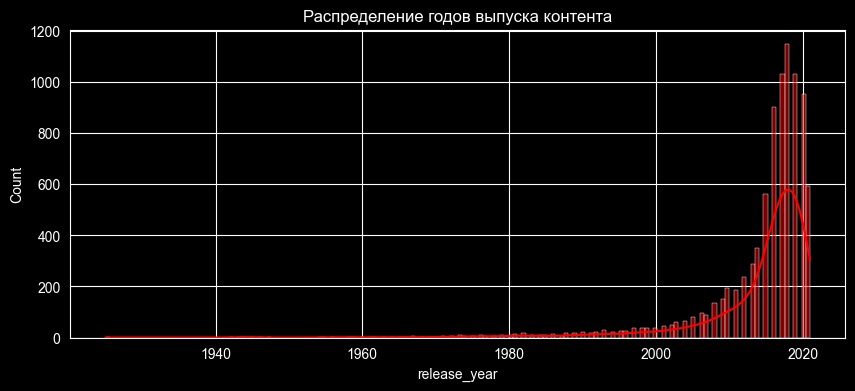

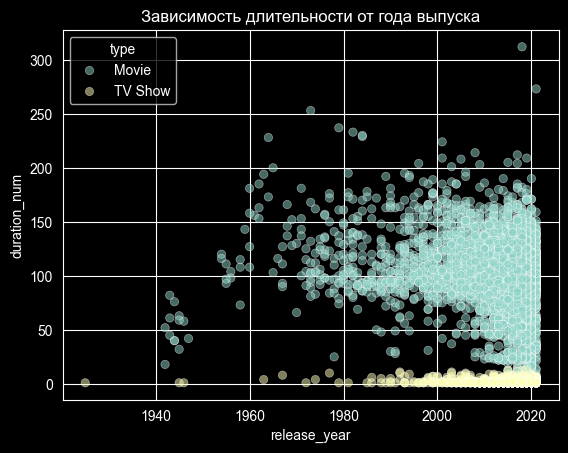

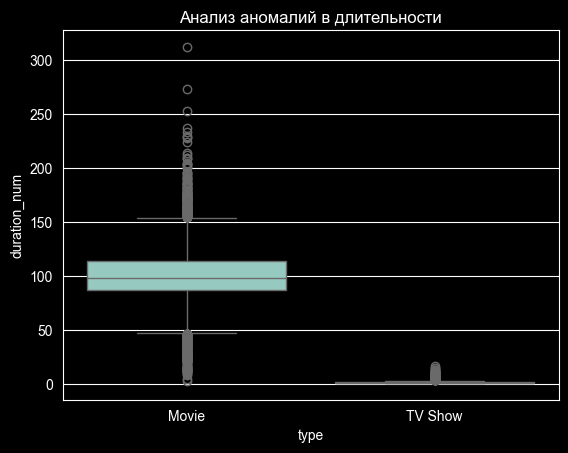

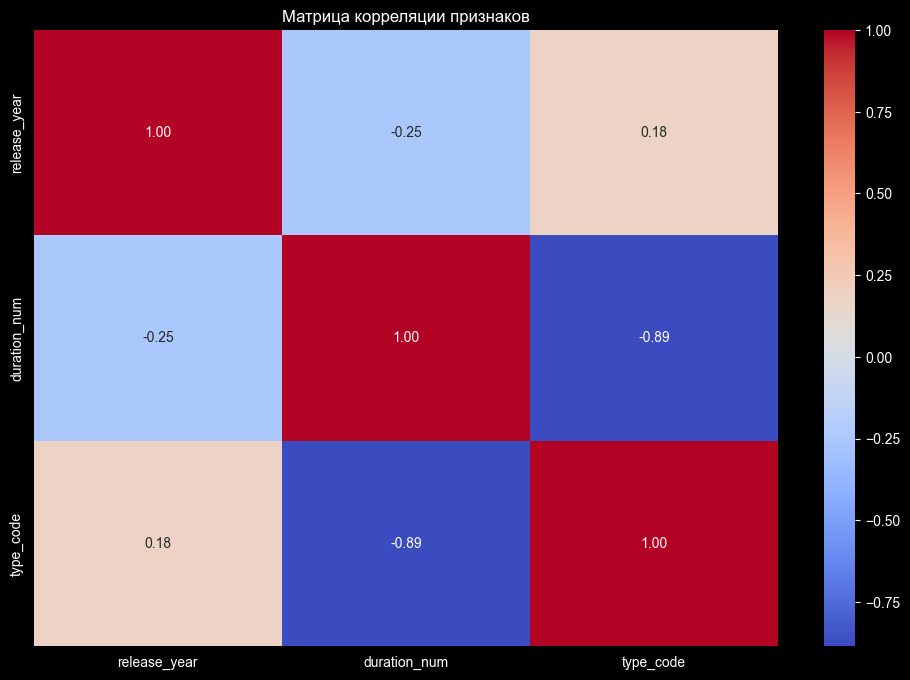

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pandas as pd
df = pd.read_csv('netflix_titles.csv')
plt.figure(figsize=(10, 4))
sns.histplot(df['release_year'], kde=True, color='red')
plt.title('Распределение годов выпуска контента')
plt.show()

df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)
sns.scatterplot(x='release_year', y='duration_num', hue='type', data=df, alpha=0.5)
plt.title('Зависимость длительности от года выпуска')
plt.show()


sns.boxplot(x='type', y='duration_num', data=df)
plt.title('Анализ аномалий в длительности')
plt.show()

df_genres = df.assign(genre=df['listed_in'].str.split(', ')).explode('genre')
df_clean = df_genres.dropna(subset=['genre', 'rating'])
fig = px.treemap(df_clean, path=['genre', 'rating'], title='Netflix: Жанры, Возраст')
fig.show()


df['type_code'] = df['type'].map({'Movie': 0, 'TV Show': 1})
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Матрица корреляции признаков')
plt.show()

country_count = df['country'].value_counts()
rare = country_count[country_count < 10].index
df['country_grouped'] = df['country'].replace(rare, 'Other')
cols_to_show = ['title', 'year_added', 'month_added', 'country_grouped']
top_countries = df['country_grouped'].value_counts().head(10).reset_index()
fig = px.bar(top_countries, x='country_grouped', y='count', title='Топ-10 стран')
fig.show()

- сериалы значительно короче фильмов (корреляция −0.89)
- современные проекты немного короче старых (−0.25)
- после 2015 года сериалов стало больше (+0.18)

* Основная аудитория Netflix — взрослые и подростки.
* США является лидером по количеству производства сериалов и фильмов
* У сериалов длительность стабильная, а у фильмов сильно различается
* После 2000-х резко выросло количество и фильмов, и сериалов
* Самый ранний год выпуска 1925, а самый поздний 2021, а самый частый 2018
* Контент из Индии и Южной Кореи имеет более высокую среднюю длительность  по сравнению с европейским контентом
* Много новых фильмов/сериалов, мало старых

Гипотезы:
- На гистограммах  видно, что подавляющее большинство контента имеет рейтинги TV-MA  и TV-14 . Гипотеза: Netflix перестал быть «семейным» сервисом и фокусируется на производстве  взрослого контента.
- В будущем популярность драм, криминальных сериалов и триллеров будет расти, так как спрос на взрослый контент остаётся высоким.
- В будущем международные фильмы будут становиться всё популярнее, потому что глобальная аудитория принимает контент разных стран.
- Поскольку в большинстве жанров преобладают рейтинги TV‑MA и TV‑14,  следует фокусироваться на создании контента для подростков 14+ и взрослых, тк они являются основной аудиторией.
